In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import confusion_matrix
from sklearn.tree import DecisionTreeRegressor

# Load Dataset
df = pd.read_csv("bus_arrival_data.csv")

print("Dataset Shape:", df.shape)
print(df.head())

Dataset Shape: (1500, 7)
   distance_km  traffic_level  passenger_count  weather_condition  \
0        27.31              4               57                  2   
1        15.92              4               45                  3   
2        30.19              5               80                  2   
3        24.71              5               63                  2   
4         4.20              4                6                  1   

   time_of_day  number_of_stops  arrival_delay_minutes  
0           20               14                  11.84  
1            7                2                   7.83  
2           18               21                  13.42  
3           14               15                   9.17  
4           18               24                   2.73  


In [3]:
print(df.info())
print("\nMissing Values:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   distance_km            1500 non-null   float64
 1   traffic_level          1500 non-null   int64  
 2   passenger_count        1500 non-null   int64  
 3   weather_condition      1500 non-null   int64  
 4   time_of_day            1500 non-null   int64  
 5   number_of_stops        1500 non-null   int64  
 6   arrival_delay_minutes  1500 non-null   float64
dtypes: float64(2), int64(5)
memory usage: 82.2 KB
None

Missing Values:
distance_km              0
traffic_level            0
passenger_count          0
weather_condition        0
time_of_day              0
number_of_stops          0
arrival_delay_minutes    0
dtype: int64


In [5]:
X = df[[
"distance_km",
"traffic_level",
"passenger_count",
"weather_condition",
"time_of_day",
"number_of_stops"
]]
y = df["arrival_delay_minutes"]
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.20, random_state=42
)
print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (1200, 6)
Testing Data: (300, 6)


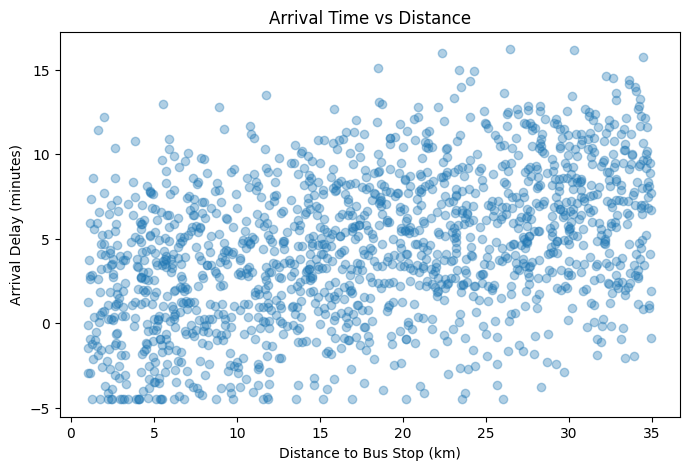

In [10]:
plt.figure(figsize=(8, 5))
plt.scatter(
    df["distance_km"],
    df["arrival_delay_minutes"],
    alpha=0.35
)
plt.xlabel("Distance to Bus Stop (km)")
plt.ylabel("Arrival Delay (minutes)")
plt.title("Arrival Time vs Distance")
plt.show()

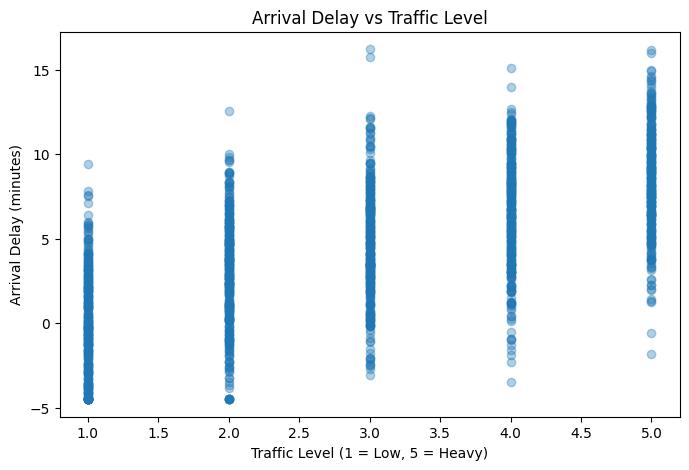

In [12]:
plt.figure(figsize=(8, 5))
plt.scatter(
df["traffic_level"],
df["arrival_delay_minutes"],
alpha=0.35
)
plt.xlabel("Traffic Level (1 = Low, 5 = Heavy)")
plt.ylabel("Arrival Delay (minutes)")
plt.title("Arrival Delay vs Traffic Level")
plt.show()

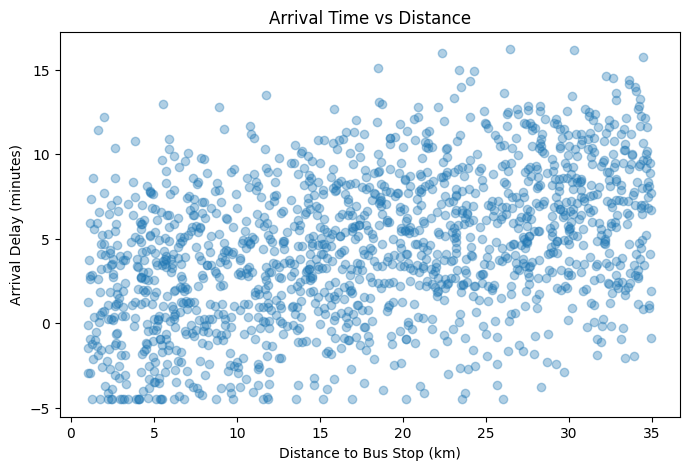

In [17]:
plt.figure(figsize=(8, 5))
plt.scatter(
    df["distance_km"],
    df["arrival_delay_minutes"],
    alpha=0.35
)
plt.xlabel("Distance to Bus Stop (km)")
plt.ylabel("Arrival Delay (minutes)")
plt.title("Arrival Time vs Distance")
plt.show()

In [20]:
model = DecisionTreeRegressor(
max_depth=8,
min_samples_leaf=5,
random_state=42
)
model.fit(X_train, y_train)
print("Model Training Completed!")

Model Training Completed!


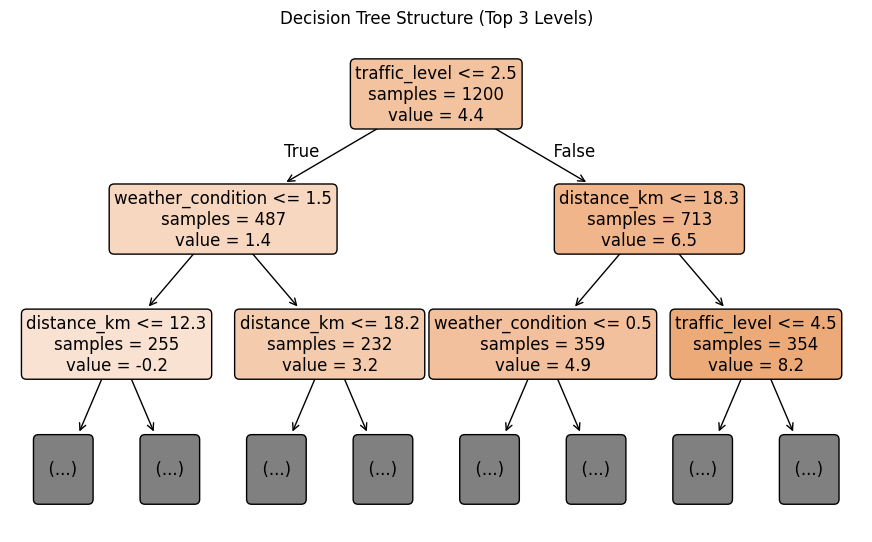

In [21]:
from sklearn.tree import plot_tree
plt.figure(figsize=(11, 6.5))
plot_tree(
model,
max_depth=2,
feature_names=X.columns,
filled=True,
rounded=True,
impurity=False,
precision=1,
fontsize=12
)
plt.title("Decision Tree Structure (Top 3 Levels)")
plt.show()

In [22]:
y_pred = model.predict(X_test)
print("Predicted Arrival Time (minutes):")
print(y_pred[:10])

Predicted Arrival Time (minutes):
[-2.10666667  7.19285714  2.35444444  1.14        1.61727273  9.3
  6.462       2.036       6.74875     6.27965517]


In [23]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(
mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print("MAE :", mae)
print("RMSE:", rmse)
print("R2 :", r2)

MAE : 1.8831569289186647
RMSE: 2.3131566859396853
R2 : 0.7058903746863638


In [26]:
sample = pd.DataFrame([
{
"distance_km": 5,
"traffic_level": 3,
"passenger_count": 30,
"weather_condition": 1,
"time_of_day": 10,
"number_of_stops": 10
}
])
prediction = model.predict(sample)[0]
prediction = max(prediction, 0)
print("Predicted Arrival Time:",
round(prediction, 2), "minutes")
if prediction <= 10:
    print("Status: ARRIVING SOON")
elif prediction <= 25:
    print("Status: ON THE WAY")
else:
    print("Status: FAR AWAY")

Predicted Arrival Time: 2.13 minutes
Status: ARRIVING SOON
